In [1]:
import os, torch, tifffile as tiff
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T


In [2]:

class MicroCTDatasetTest(Dataset):
    def __init__(self, img_dir, mask_dir=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(".tif")])
        if mask_dir:
            self.mask_files = [f.replace("image_v2_", "image_v2_mask_") for f in self.img_files]
        else:
            self.mask_files = None
        
        self.resize = T.Resize((768,768), interpolation=T.InterpolationMode.BILINEAR)

    def __len__(self): 
        return len(self.img_files)

    def __getitem__(self, idx):
        img = tiff.imread(os.path.join(self.img_dir, self.img_files[idx]))
        if img.ndim == 3: img = img[img.shape[0]//2]

        img = img.astype(np.float32)
        img /= img.max()

        img = Image.fromarray(img)
        img = self.resize(img)
        img = np.array(img, dtype=np.float32)
        img = torch.tensor(img).unsqueeze(0)

        if self.mask_dir is None:
            return img, None

        mask = tiff.imread(os.path.join(self.mask_dir, self.mask_files[idx]))
        if mask.ndim == 3: mask = mask[mask.shape[0]//2]
        mask = (mask > 0).astype(np.float32)
        mask = Image.fromarray(mask)
        mask = self.resize(mask)
        mask = torch.tensor(np.array(mask)).unsqueeze(0)

        return img, mask


In [13]:
import sys
import os

# Add the parent directory of 'src' to sys.path
sys.path.append(os.path.abspath(os.path.join('..', )))

# Now you can import
from utils.dataset_loader_vit import TOMODatasetViT

test_ds = TOMODatasetViT(
    img_dir="../../datas/original/test/imgs",
    label_dir="../../datas/original/test/labels",
    split=None,
    resized_shape=[768, 768],
    transform=None
)

test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
print("Test samples:", len(test_ds))


Test samples: 5


In [14]:
def dice_metric(p, t, eps=1e-6):
    p = (p.reshape(-1) > 0.5).float()
    t = t.reshape(-1).float()
    i = (p * t).sum()
    u = p.sum() + t.sum()
    return (2*i + eps) / (u + eps)

In [18]:
# ======= TEST.IPYNB =======
import os, torch, numpy as np, matplotlib.pyplot as plt, tifffile as tiff
import torch.nn.functional as F, torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset
from models.Unet_ViT import U_net_ViT

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=U_net_ViT(
    encode_in=(1,64,128,256), encode_out=(64,128,256,512),
    decode_in=(1024,512,256,128), decode_out=(512,256,128,64),
    normalize=True
)
model.load_state_dict(torch.load("../../models/predicted_models/unet_vit_trained.pth", map_location=device))
model.to(device); model.eval()


U_net_ViT(
  (encode): ModuleList(
    (0): EncodeBlock(
      (conv_block): Convblock(
        (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bNorm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bNorm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (dropout): Dropout2d(p=0.2, inplace=False)
        (activation): ReLU(inplace=True)
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncodeBlock(
      (conv_block): Convblock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bNorm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bNorm2): BatchNorm2d(128, 

Size: torch.Size([1, 1024, 96, 96])
Size: torch.Size([1, 512, 96, 96])
Size: torch.Size([1, 1024, 96, 96])
Size: torch.Size([1, 512, 192, 192])
Size: torch.Size([1, 256, 192, 192])
Size: torch.Size([1, 512, 192, 192])
Size: torch.Size([1, 256, 384, 384])
Size: torch.Size([1, 128, 384, 384])
Size: torch.Size([1, 256, 384, 384])
Size: torch.Size([1, 128, 768, 768])
Size: torch.Size([1, 64, 768, 768])
Size: torch.Size([1, 128, 768, 768])


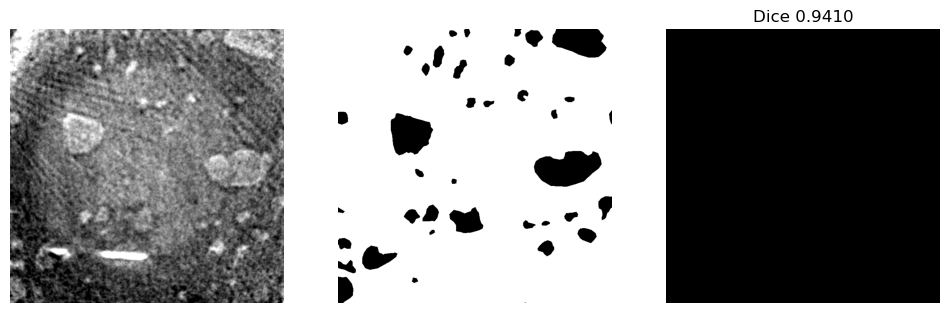

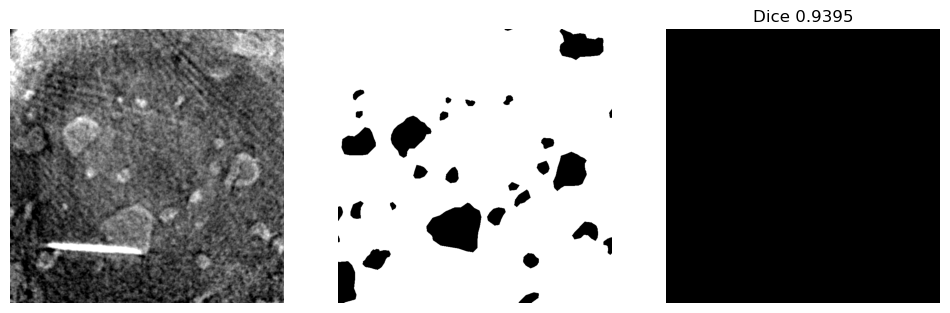

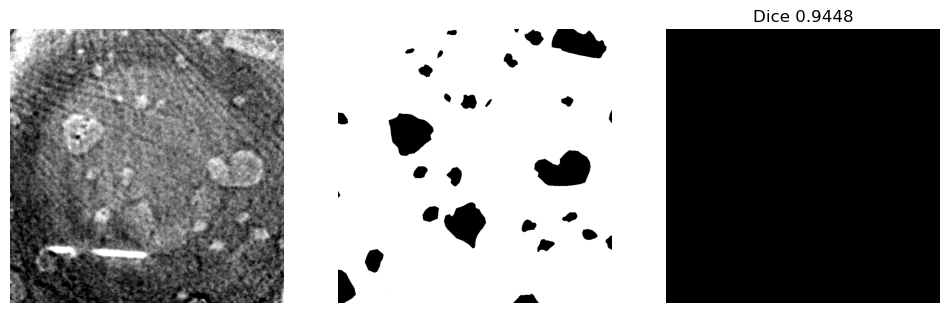

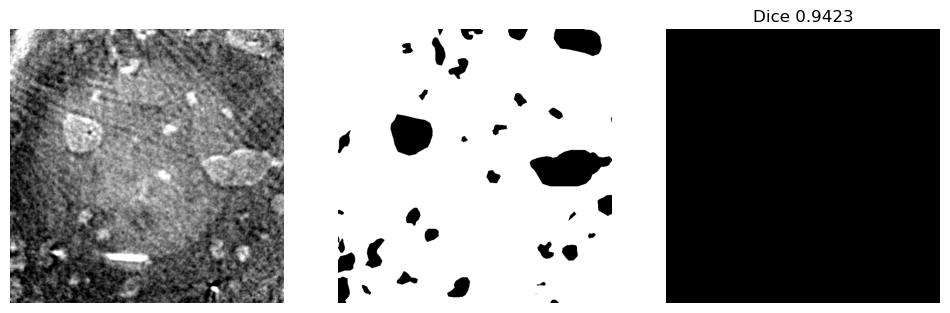

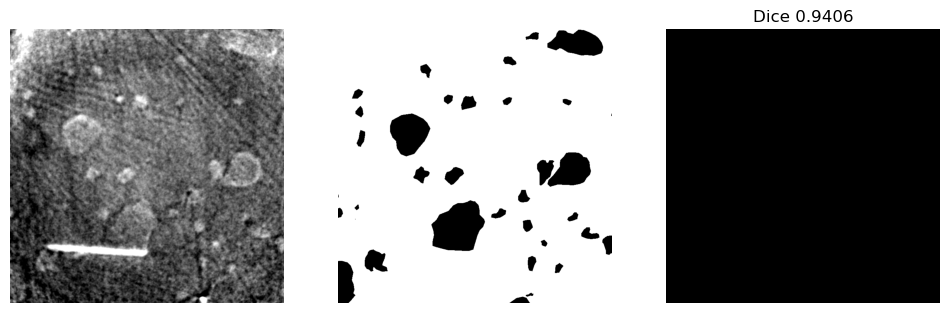

TEST SET | mean Dice=0.9417 | std=0.0018


In [19]:
all_d = []
model.eval()

with torch.no_grad():
    for i, (img, gt) in enumerate(test_loader):
        img = img.to(device)
        gt = gt.to(device)

        # pred = torch.sigmoid(model(img))
        out = model(img)
        if isinstance(out, tuple):
            out = out[0]

        pred = torch.sigmoid(out)

        pred_bin = (pred > 0.5).float()

        d = dice_metric(pred_bin, gt).item()
        all_d.append(d)

        # Visualization
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(img[0,0].cpu(), cmap="gray")
        axs[1].imshow(gt[0,0].cpu(), cmap="gray")
        axs[2].imshow(pred_bin[0,0].cpu(), cmap="gray")
        axs[2].set_title(f"Dice {d:.4f}")
        for a in axs: a.axis("off")
        plt.show()

mean = np.mean(all_d)
std = np.std(all_d)
print(f"TEST SET | mean Dice={mean:.4f} | std={std:.4f}")
